In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [8]:
train_df = pd.read_csv("../datasets/train.csv")
test_df = pd.read_csv("../datasets/test.csv")

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

Training shape: (668665, 15)
Test shape: (286571, 14)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,"92,887.00",23.40,2,3,7,1.00,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,"30,000.00",5.00,1,2,2,4.00,Male,Rural,SUV,Yes,No,Low,No
2,2,26,"94,389.00",36.80,1,8,15,5.00,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,"73,580.00",23.70,2,6,9,3.00,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,"57,898.00",50.80,1,2,3,3.00,Male,Suburban,Hatchback,Yes,No,Low,No


# Structure Inspection

In [9]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

In [10]:
print("Columns:")
print(train_df.columns.tolist())

Columns:
['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV']


In [11]:
display(train_df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,"668,665.00",NaN,NaN,NaN,"334,332.00","193,027.10",0.00,"167,166.00","334,332.00","501,498.00","668,664.00"
Age,"668,665.00",NaN,NaN,NaN,47.04,12.88,25.00,36.00,47.00,58.00,69.00
Annual_Income_USD,"668,665.00",NaN,NaN,NaN,"84,769.27","28,648.03","30,000.00","67,376.00","84,880.00","102,753.00","188,549.00"
Daily_Commute_km,"668,665.00",NaN,NaN,NaN,32.16,18.73,5.00,17.20,33.60,47.40,98.70
Number_of_Cars_Owned,"668,665.00",NaN,NaN,NaN,1.71,0.73,1.00,1.00,2.00,2.00,4.00
Charging_Stations_Near_Home,"668,665.00",NaN,NaN,NaN,4.96,3.93,0.00,2.00,4.00,7.00,14.00
Charging_Stations_Near_Work,"668,665.00",NaN,NaN,NaN,7.18,5.19,0.00,3.00,6.00,10.00,19.00
Environmental_Concern_Level,"668,665.00",NaN,NaN,NaN,2.94,1.43,1.00,2.00,3.00,4.00,5.00
Gender,668665,3,Male,367954,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City_Type,668665,3,Urban,289305,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Target Examination

,count,percentage
Will_Buy_EV,,
No,551886,82.54
Yes,116779,17.46


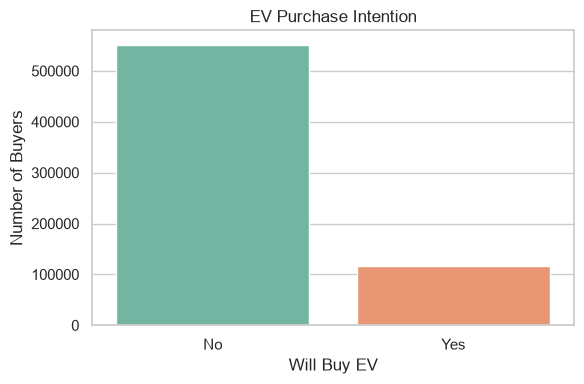

In [17]:
TARGET = "Will_Buy_EV"

target_counts = train_df[TARGET].value_counts()
target_percentages = (
    train_df[TARGET].value_counts(normalize=True) * 100
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages,
})

display(target_summary)

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=train_df,
    x=TARGET,
    hue=TARGET,
    palette="Set2",
    legend=False,
)

ax.set_title("EV Purchase Intention")
ax.set_xlabel("Will Buy EV")
ax.set_ylabel("Number of Buyers")

plt.tight_layout()
plt.show()

# Numerical Exploration

In [18]:
numeric_columns = train_df.select_dtypes(
    include=np.number
).columns.tolist()

print(numeric_columns)

['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']


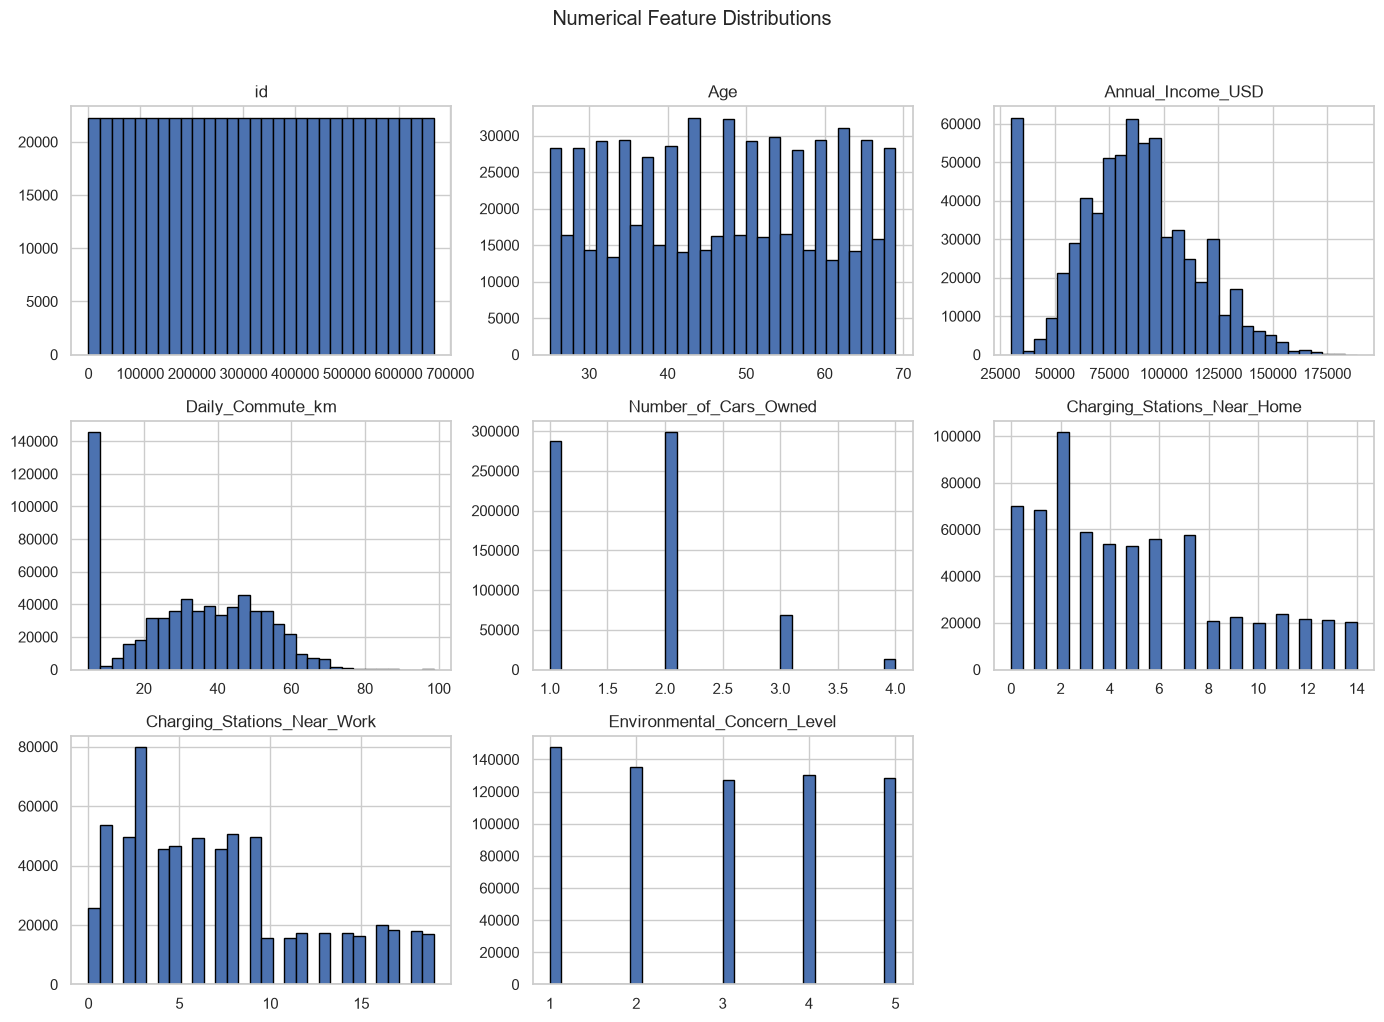

In [19]:
train_df[numeric_columns].hist(
    figsize=(14, 10),
    bins=30,
    edgecolor="black",
)

plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

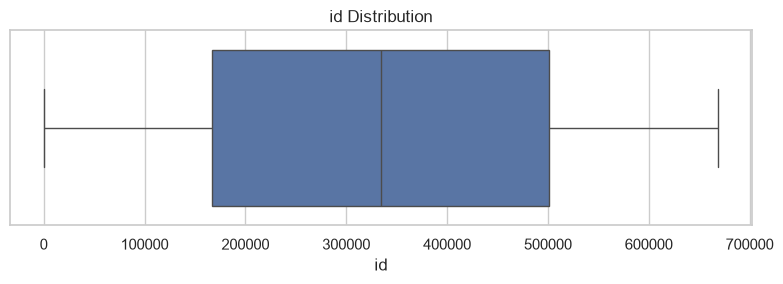

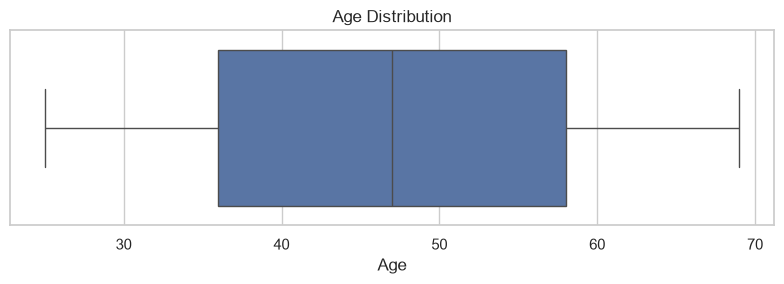

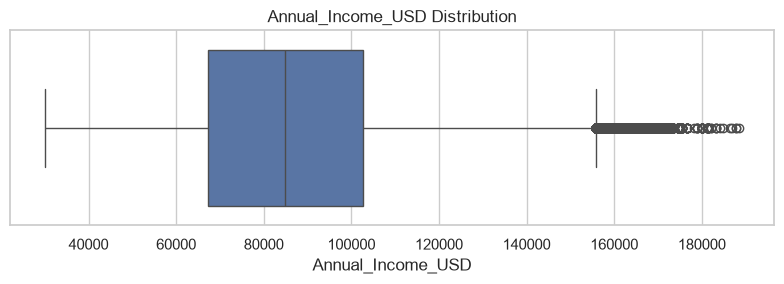

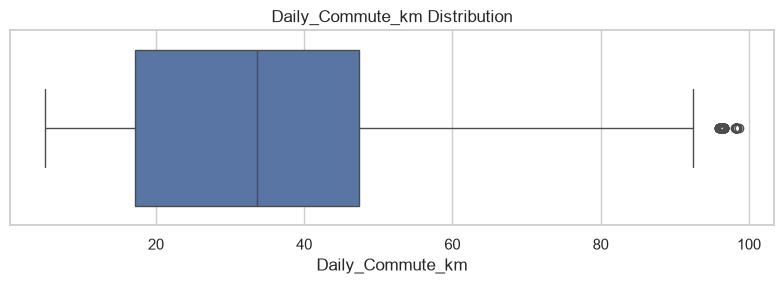

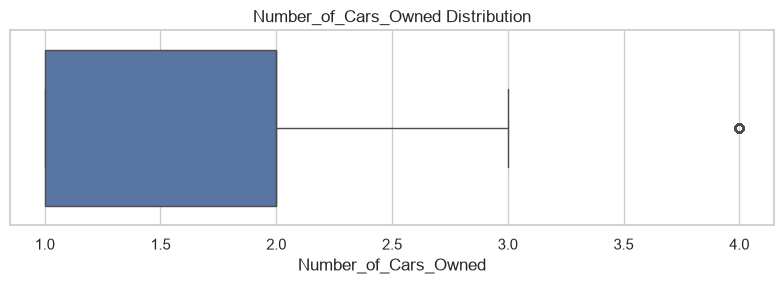

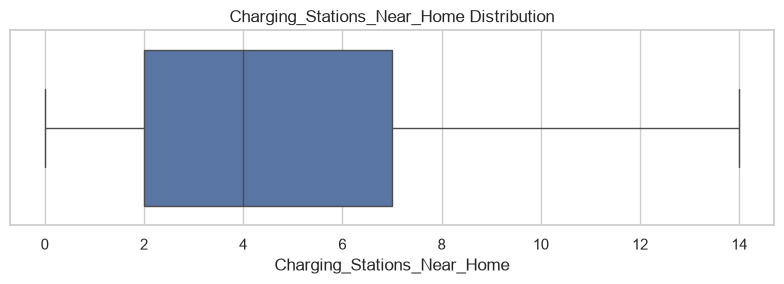

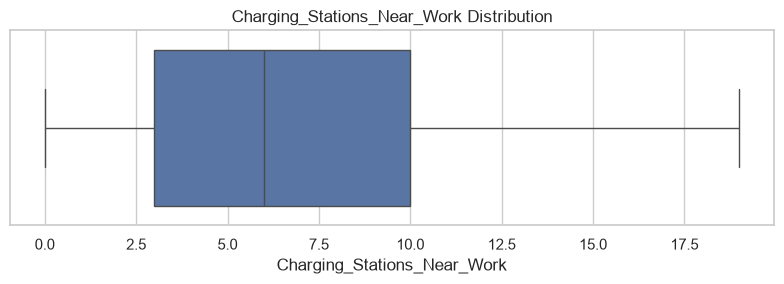

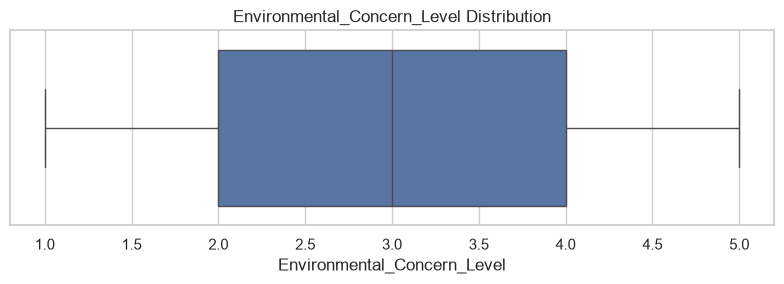

In [ ]:
# Boxplot Outlier Analysis
for column in numeric_columns:
    plt.figure(figsize=(8, 3))

    sns.boxplot(
        data=train_df,
        x=column,
    )

    plt.title(f"{column} Distribution")
    plt.tight_layout()
    plt.show()

# Numerical analysis in comparison to Purchase Intention

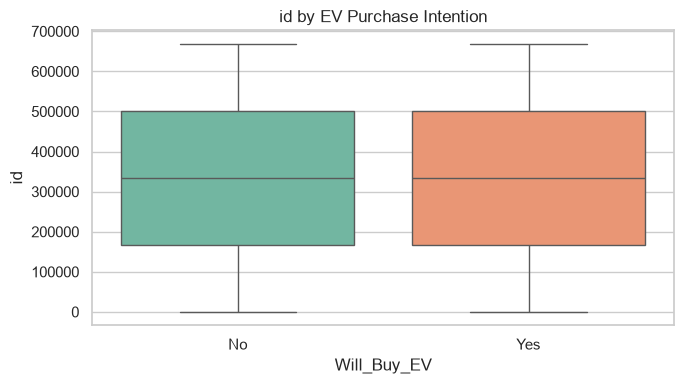

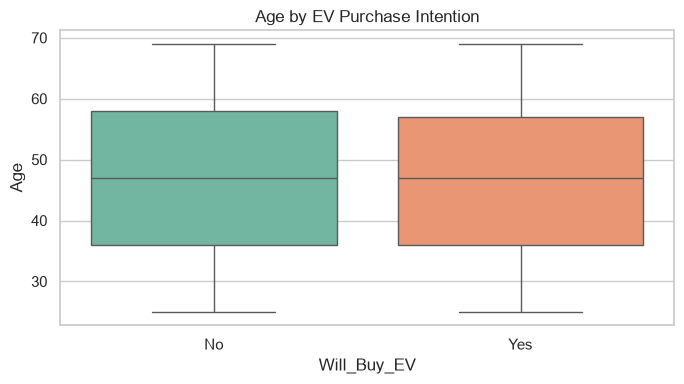

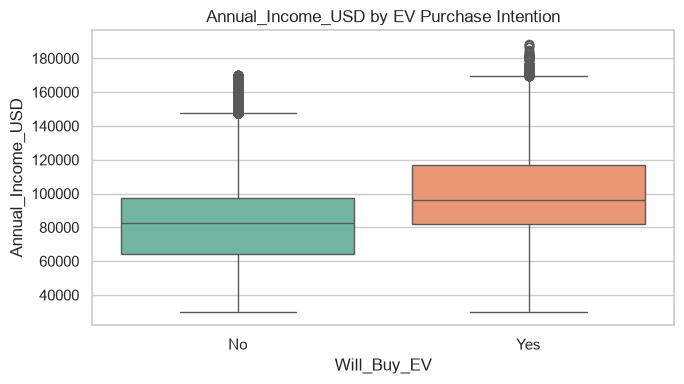

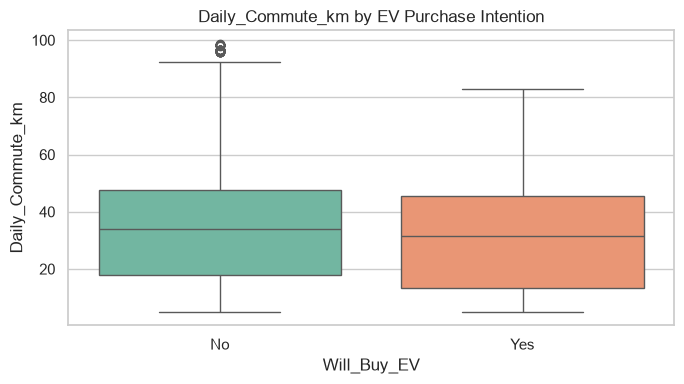

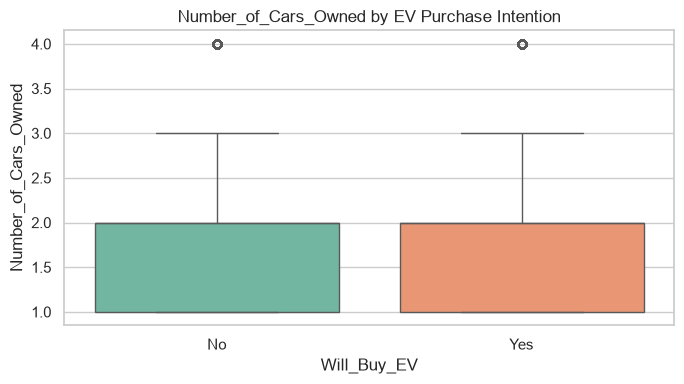

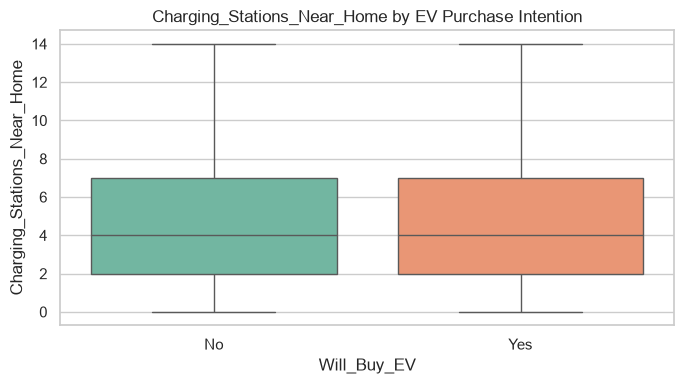

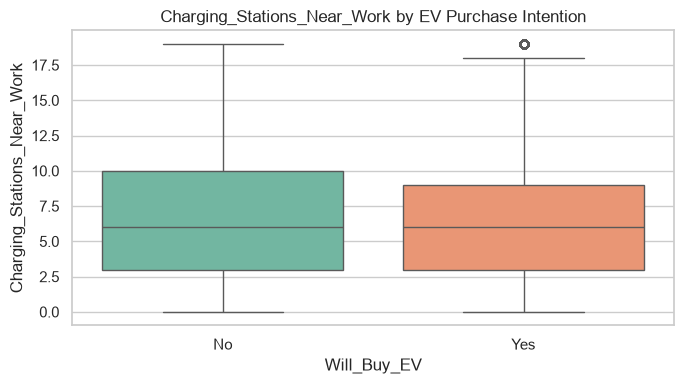

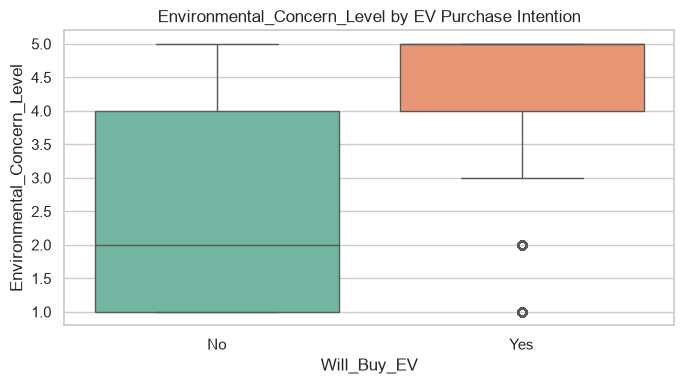

In [21]:
for column in numeric_columns:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=train_df,
        x=TARGET,
        y=column,
        hue=TARGET,
        legend=False,
        palette="Set2",
    )

    plt.title(f"{column} by EV Purchase Intention")
    plt.tight_layout()
    plt.show()